Load & Combine Data

In [3]:
import pandas as pd

countries = ['ethiopia', 'sudan', 'kenya', 'nigeria', 'tanzania']

dfs = []
for c in countries:
    df = pd.read_csv(f"../../dataset/{c}_clean.csv")
    df['Country'] = c.capitalize()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Clean column names (important)
df_all.columns = df_all.columns.str.strip()

# Ensure datetime
df_all['Date'] = pd.to_datetime(df_all['Date'])
df_all.set_index('Date', inplace=True)

print(df_all.head())

            YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
Date                                                                            
2015-01-01  2015    1  11.73    22.75     3.44      19.31          0.0  41.79   
2015-01-02  2015    2  12.30    24.01     4.09      19.92          0.0  33.29   
2015-01-03  2015    3  12.49    24.17     3.97      20.20          0.0  33.83   
2015-01-04  2015    4  14.08    23.78     6.90      16.88          0.0  38.84   
2015-01-05  2015    5  14.06    23.15     7.32      15.83          0.0  47.07   

            WS2M  WS2M_MAX     PS  QV2M   Country  Month  
Date                                                      
2015-01-01  2.73      5.07  77.13  4.00  Ethiopia      1  
2015-01-02  2.39      4.19  77.14  3.35  Ethiopia      1  
2015-01-03  1.77      2.76  77.11  3.43  Ethiopia      1  
2015-01-04  0.87      1.28  77.07  4.60  Ethiopia      1  
2015-01-05  1.34      2.14  77.01  5.58  Ethiopia      1  


Temperature Trend Comparison

Monthly T2M Plot

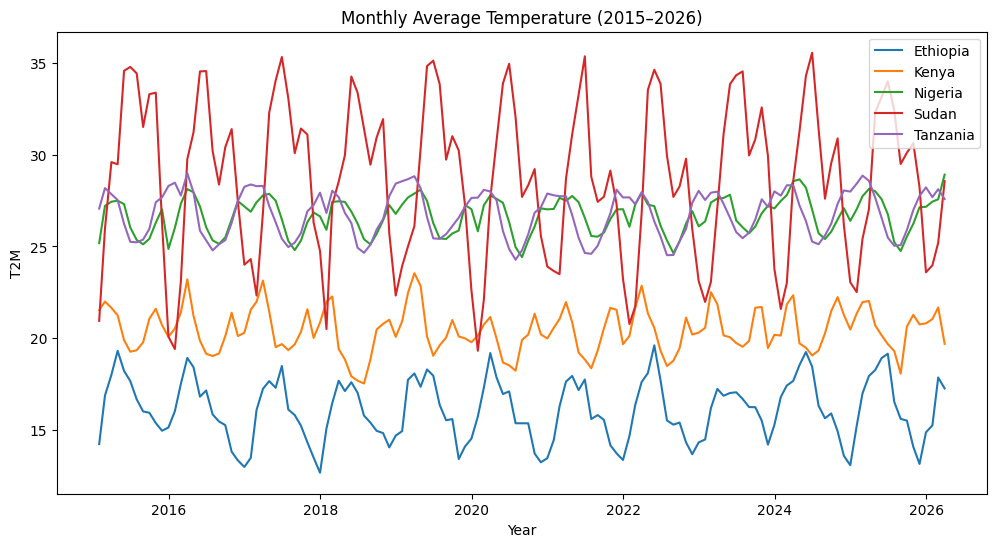

In [5]:
import matplotlib.pyplot as plt

monthly_t2m = df_all.groupby('Country').resample('ME')['T2M'].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_t2m['Country'].unique():
    subset = monthly_t2m[monthly_t2m['Country'] == country]
    plt.plot(subset['Date'], subset['T2M'], label=country)

plt.legend()
plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("T2M")
plt.show()

Summary Table (Temperature (T2M))

In [6]:
temp_summary = df_all.groupby('Country')['T2M'].agg(['mean','median','std'])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068679,16.04,1.897501
Kenya,20.427483,20.36,1.438281
Nigeria,26.659160,26.82,1.115192
Sudan,28.759607,29.16,4.679431
Tanzania,26.802458,26.99,1.325279


Precipitation Variability Comparison

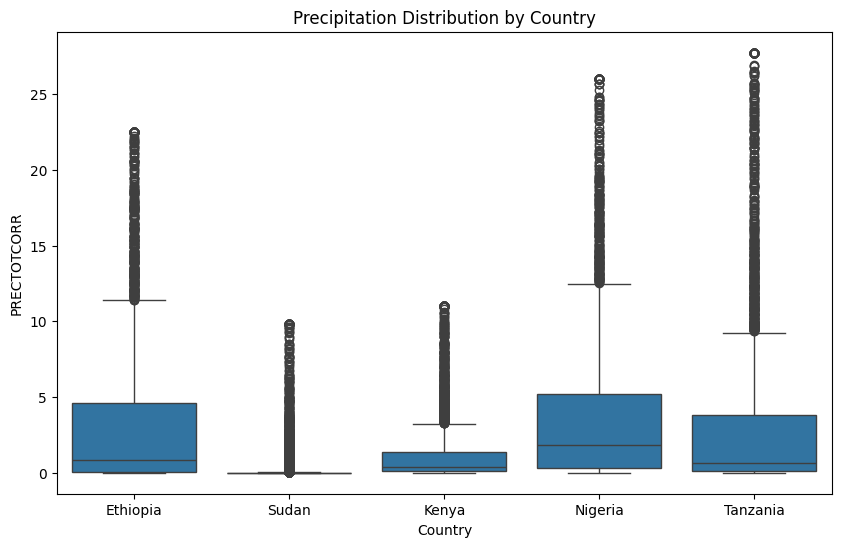

In [7]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x='Country', y='PRECTOTCORR', data=df_all)
plt.title("Precipitation Distribution by Country")
plt.show()

Summary Table for PRECTOTCORR across countries

In [8]:
precip_summary = df_all.groupby('Country')['PRECTOTCORR'].agg(['mean','median','std'])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.440719,0.82,5.374903
Kenya,1.323742,0.38,2.282832
Nigeria,3.950704,1.84,5.454583
Sudan,0.487103,0.00,1.665770
Tanzania,3.420823,0.64,6.002178


Extreme Event Frequency

T2M_MAX exceeds 35°C (extreme heat)

In [10]:
df_all['Year'] = df_all.index.year

extreme_heat = df_all[df_all['T2M_MAX'] > 35]

heat_counts = (
    extreme_heat
    .groupby(['Country','Year'])
    .size()
    .reset_index(name='Extreme_Heat_Days')
)

consecutive dry days per year (days where PRECTOTCORR < 1 mm)

In [11]:
df_all['Dry'] = df_all['PRECTOTCORR'] < 1

def count_consecutive(series):
    max_count = count = 0
    for val in series:
        if val:
            count += 1
            max_count = max(max_count, count)
        else:
            count = 0
    return max_count

dry_spells = (
    df_all
    .groupby(['Country','Year'])['Dry']
    .apply(count_consecutive)
    .reset_index(name='Max_Dry_Spell')
)

Visualization

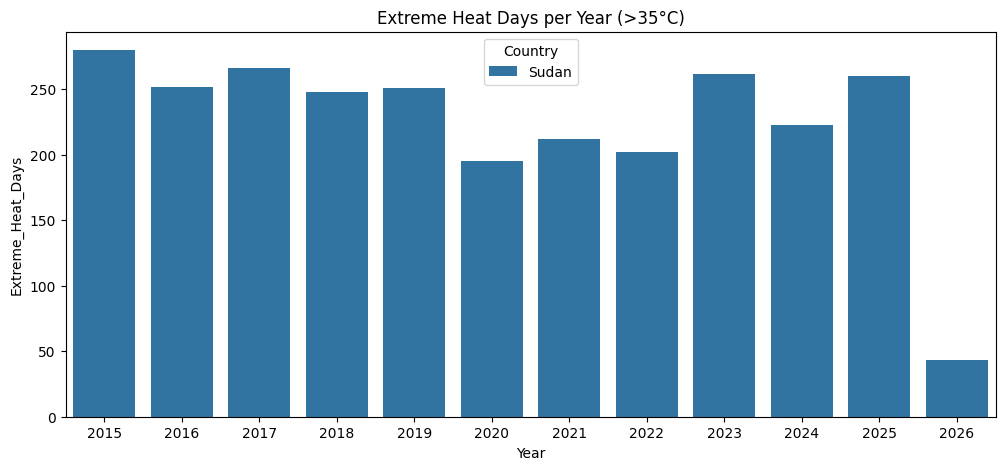

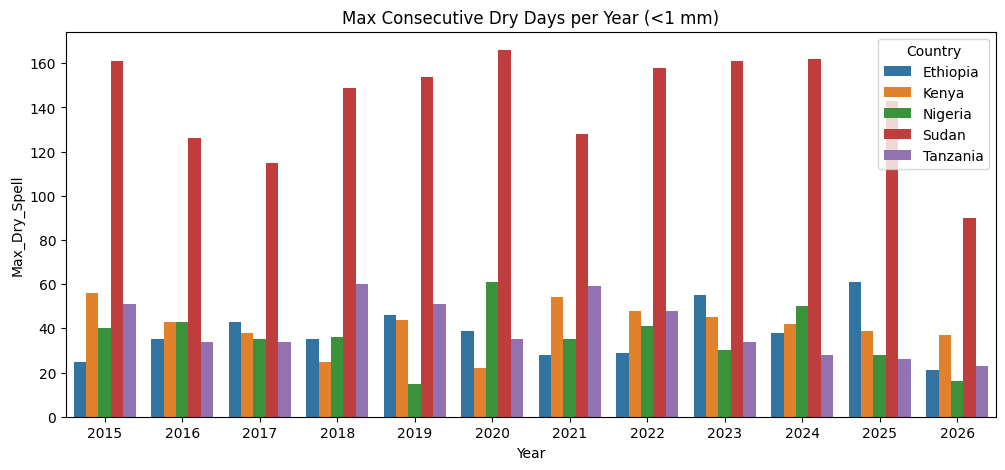

In [12]:
# Extreme heat
plt.figure(figsize=(12,5))
sns.barplot(data=heat_counts, x='Year', y='Extreme_Heat_Days', hue='Country')
plt.title("Extreme Heat Days per Year (>35°C)")
plt.show()

# Dry spells
plt.figure(figsize=(12,5))
sns.barplot(data=dry_spells, x='Year', y='Max_Dry_Spell', hue='Country')
plt.title("Max Consecutive Dry Days per Year (<1 mm)")
plt.show()

Statistical Testing

In [15]:
from scipy.stats import f_oneway

groups = [
    df_all[df_all['Country'] == c]['T2M'].dropna()
    for c in df_all['Country'].unique()
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 18969.818700710854
p-value: 0.0


Interpretation:


Vulnerability Ranking

In [14]:
ranking = pd.DataFrame(index=temp_summary.index)

ranking['Temp_Mean'] = temp_summary['mean']
ranking['Precip_Var'] = precip_summary['std']

ranking['Heat_Events'] = (
    heat_counts.groupby('Country')['Extreme_Heat_Days'].mean()
)

ranking['Dry_Spells'] = (
    dry_spells.groupby('Country')['Max_Dry_Spell'].mean()
)

# Normalize (important improvement)
ranking = (ranking - ranking.min()) / (ranking.max() - ranking.min())

# Composite score
ranking['Vulnerability_Score'] = ranking.sum(axis=1)

ranking = ranking.sort_values(by='Vulnerability_Score', ascending=False)

ranking

,Temp_Mean,Precip_Var,Heat_Events,Dry_Spells,Vulnerability_Score
Country,,,,,
Sudan,1.000000,0.000000,NaN,1.000000,2.000000
Tanzania,0.845784,1.000000,NaN,0.041309,1.887093
Nigeria,0.834492,0.873722,NaN,0.000000,1.708214
Ethiopia,0.000000,0.855347,NaN,0.019486,0.874832
Kenya,0.343458,0.142298,NaN,0.049104,0.534860


Key Observations:
    

Which country is warming fastest and what does the trend suggest?
    •	Sudan appears to be warming the fastest, as it has the highest normalized temperature mean (1.00)

Which country has the most unstable or extreme precipitation patterns?
    •	Tanzania shows the highest precipitation variability (1.00), followed closely by Nigeria (0.87) and Ethiopia (0.86)

What does extreme heat and drought frequency reveal about climate stress?
    
    •	Sudan faces the highest climate stress from drought as Dry spells are highest in Sudan (1.00)
    
    •	Nigeria shows the lowest dry spell intensity (0.00), suggesting relatively more consistent rainfall

How does Ethiopia's climate profile compare to its neighbors?
    
    •	Ethiopia shows a mixed vulnerability profile

            - Lowest temperature score (0.00) → relatively cooler climate 

            - High precipitation variability (0.86) → significant rainfall instability 

            - Low dry spell intensity (~0.02) → fewer prolonged droughts than Sudan

    •	Compared to neighbors:

            - Less extreme dry than Sudan : has lower Temp_mean  - 0.000000 and lower dry spell - 0.019486

            - More stable than Tanzania in precipitation: has lower precipitation variability – 0.86
            
            - More vulnerable than Kenya overall : has lower temperature - 0.000000 and low vulnerability score - 0.874832


Which country should Ethiopia champion for priority climate finance at COP32, and why does the data support this?

    Sudan has

        •	Highest overall vulnerability score (2.00) 

        •	Highest temperature exposure (1.00) → strongest warming signal 

        •	Highest drought intensity (1.00) → severe water stress

    Hence, Sudan should be prioritized for climate finance.
    
